In [96]:
import matplotlib.pyplot as plt

In [97]:
import os

import numpy as np
import pandas as pd

In [98]:
def parse_forecast_file(file_path):
    """
    Parse forecast file and extract date-price data
    """
    dates = []
    prices = []

    with open(file_path, "r") as file:
        lines = file.readlines()

        # Find the start of forecast data
        start_reading = False
        for line in lines:
            line = line.strip()

            if line == "Forecast Data:":
                start_reading = True
                continue

            if start_reading and line.startswith("----"):
                continue

            if start_reading and line.startswith("Overall Statistics:"):
                break

            if start_reading and ":" in line and line != "Forecast Data:":
                try:
                    date_str, price_str = line.split(": ")
                    dates.append(pd.to_datetime(date_str))
                    prices.append(float(price_str))
                except ValueError:
                    continue

    return dates, prices

In [99]:
# Define the forecast price folder path
forecast_folder = "forecast_price"

# Define crop names and their corresponding file names
crops = {
    "Cassava": "cassava_forecast.txt",
    "Corn": "corn_forecast.txt",
    "Green Bean": "green_bean_forecast.txt",
    "Soybean": "soybean_forecast.txt",
}

In [100]:
crop_data = {}

for crop_name, file_name in crops.items():
    file_path = os.path.join(forecast_folder, file_name)

    if os.path.exists(file_path):
        dates, prices = parse_forecast_file(file_path)
        crop_data[crop_name] = {"dates": dates, "prices": prices}
        print(f"Loaded {crop_name} data: {len(prices)} price points")
    else:
        print(f"Warning: {file_path} not found")

print(f"\nLoaded data for {len(crop_data)} crops")

crop_price_avg = {}

for crop_name, data in crop_data.items():
    dates = data["dates"]
    prices = data["prices"]

    if len(prices) > 0:
        avg_price = np.round(np.mean(prices), 2)
        crop_price_avg[crop_name] = avg_price
        print(f"{crop_name} average price: {avg_price:.2f}")
    else:
        print(f"No price data available for {crop_name}")


Loaded Cassava data: 12 price points
Loaded Corn data: 12 price points
Loaded Green Bean data: 12 price points
Loaded Soybean data: 12 price points

Loaded data for 4 crops
Cassava average price: 3.00
Corn average price: 11.22
Green Bean average price: 24.64
Soybean average price: 18.42


In [101]:
print(crop_price_avg["Cassava"])
print(crop_price_avg["Corn"])
print(crop_price_avg["Green Bean"])
print(crop_price_avg["Soybean"])

for crop_name, data in crop_data.items():
    new_data_lst = []

    # Access the 'prices' list from the data dictionary
    for price in data["prices"]:
        if price != 0:
            new_data_lst.append(price / float(crop_price_avg[crop_name]))

    # Update the prices with normalized values
    crop_data[crop_name]["prices"] = new_data_lst

print(crop_data["Cassava"])
print(crop_data["Corn"])
print(crop_data["Green Bean"])
print(crop_data["Soybean"])

3.0
11.22
24.64
18.42
{'dates': [Timestamp('2024-01-01 00:00:00'), Timestamp('2024-02-01 00:00:00'), Timestamp('2024-03-01 00:00:00'), Timestamp('2024-04-01 00:00:00'), Timestamp('2024-05-01 00:00:00'), Timestamp('2024-06-01 00:00:00'), Timestamp('2024-07-01 00:00:00'), Timestamp('2024-08-01 00:00:00'), Timestamp('2024-09-01 00:00:00'), Timestamp('2024-10-01 00:00:00'), Timestamp('2024-11-01 00:00:00'), Timestamp('2024-12-01 00:00:00')], 'prices': [1.1666666666666667, 1.1033333333333333, 1.07, 1.0466666666666666, 1.0233333333333332, 1.0, 0.9766666666666667, 0.9566666666666667, 0.9366666666666666, 0.9166666666666666, 0.9, 0.8866666666666667]}
{'dates': [Timestamp('2024-01-01 00:00:00'), Timestamp('2024-02-01 00:00:00'), Timestamp('2024-03-01 00:00:00'), Timestamp('2024-04-01 00:00:00'), Timestamp('2024-05-01 00:00:00'), Timestamp('2024-06-01 00:00:00'), Timestamp('2024-07-01 00:00:00'), Timestamp('2024-08-01 00:00:00'), Timestamp('2024-09-01 00:00:00'), Timestamp('2024-10-01 00:00:00'),

In [102]:
def find_intersections(dates1, prices1, dates2, prices2):
    """
    Find intersection points between two price curves
    """
    intersections = []

    # Find common dates between the two datasets
    common_dates = []
    common_prices1 = []
    common_prices2 = []

    for i, date1 in enumerate(dates1):
        if date1 in dates2:
            j = dates2.index(date1)
            common_dates.append(date1)
            common_prices1.append(prices1[i])
            common_prices2.append(prices2[j])

    # Find sign changes in price differences (indicates intersection)
    for i in range(len(common_prices1) - 1):
        diff1 = common_prices1[i] - common_prices2[i]
        diff2 = common_prices1[i + 1] - common_prices2[i + 1]

        # Check if there's a sign change (intersection)
        if diff1 * diff2 < 0:
            # Linear interpolation to find exact intersection point
            t = abs(diff1) / (abs(diff1) + abs(diff2))
            intersect_date = (
                common_dates[i] + (common_dates[i + 1] - common_dates[i]) * t
            )
            intersect_price = (
                common_prices1[i] + (common_prices1[i + 1] - common_prices1[i]) * t
            )

            intersections.append((intersect_date, intersect_price))

    return intersections

In [ ]:
# Configuration and styling
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fill_colors = colors
line_styles = ["-"] * 4


def calculate_statistics(crop_data):
    """Calculate comprehensive statistics for all crops"""
    all_prices = []
    for data in crop_data.values():
        all_prices.extend(data["prices"])

    stats = {
        "avg_normalized": np.mean(all_prices),
        "std_normalized": np.std(all_prices),
        "num_crops": len(crop_data),
    }
    return stats, all_prices


def plot_crop_lines(ax, crop_data, colors, fill_colors):
    """Plot crop price lines with fill areas"""
    for i, (crop_name, data) in enumerate(crop_data.items()):
        ax.plot(
            data["dates"],
            data["prices"],
            color=colors[i],
            linewidth=2.5,
            marker="o",
            markersize=6,
            label=crop_name,
            alpha=0.9,
        )
        ax.fill_between(data["dates"], data["prices"], alpha=0.2, color=fill_colors[i])


def plot_intersections(ax, crop_data):
    """Find and plot intersection points"""
    crop_names = list(crop_data.keys())
    intersection_info = []

    for i in range(len(crop_names)):
        for j in range(i + 1, len(crop_names)):
            crop1, crop2 = crop_names[i], crop_names[j]
            intersections = find_intersections(
                crop_data[crop1]["dates"],
                crop_data[crop1]["prices"],
                crop_data[crop2]["dates"],
                crop_data[crop2]["prices"],
            )

            for date, price in intersections:
                ax.plot(
                    date,
                    price,
                    "ko",
                    markersize=10,
                    markerfacecolor="yellow",
                    markeredgecolor="black",
                    markeredgewidth=2,
                    zorder=10,
                )
                ax.annotate(
                    f"{crop1} ∩ {crop2}",
                    xy=(date, price),
                    xytext=(10, 10),
                    textcoords="offset points",
                    fontsize=8,
                    ha="left",
                    zorder=11,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.8),
                )
                intersection_info.append(
                    {"crop1": crop1, "crop2": crop2, "date": date, "price": price}
                )

    return intersection_info


def style_plot(ax, title, xlabel, ylabel):
    """Apply consistent styling to plot"""
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    ax.set_xlabel(xlabel, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.legend(
        loc="upper right",
    )
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

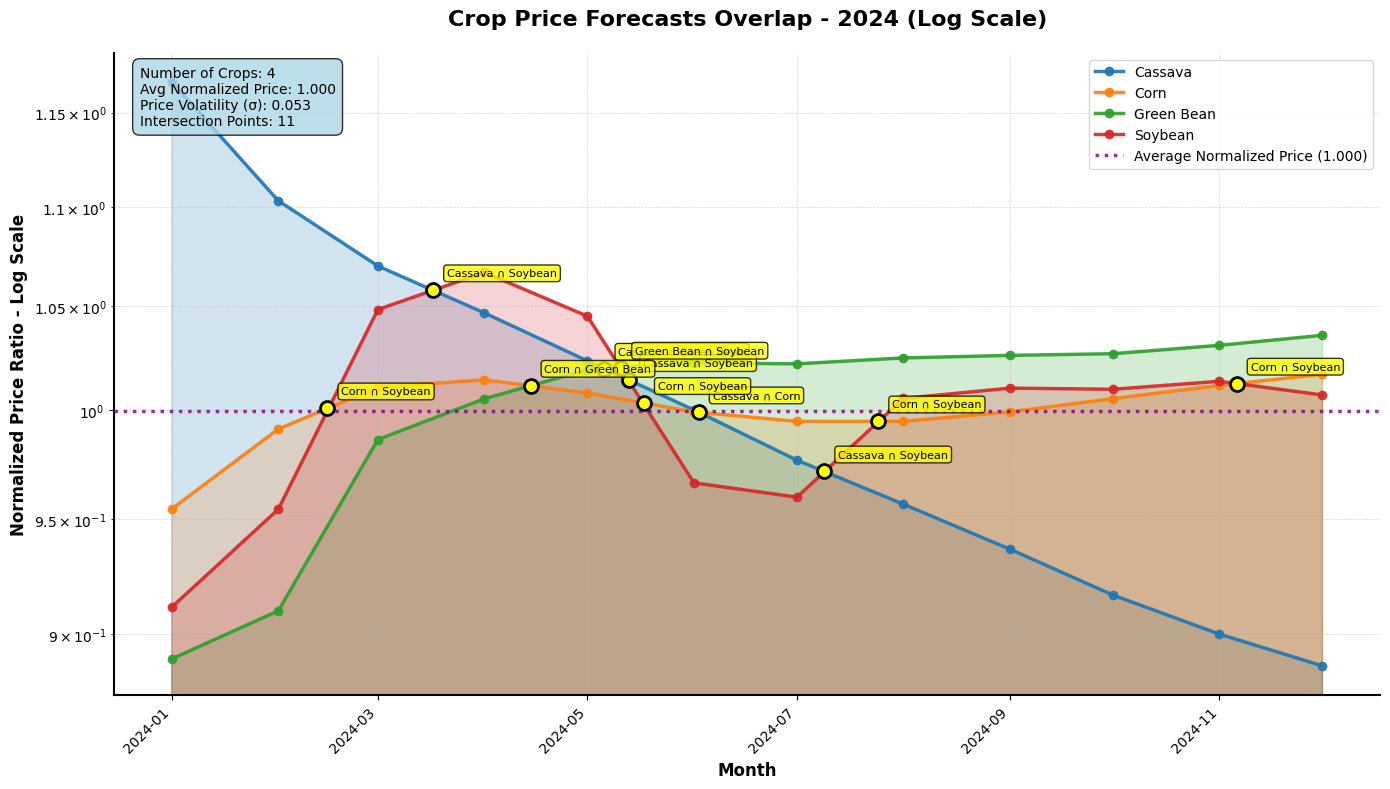

In [104]:
# Main plotting function
def create_crop_analysis_plot():
    """Create comprehensive crop price analysis plot"""
    stats, all_prices = calculate_statistics(crop_data)

    plt.figure(figsize=(14, 8))
    ax = plt.gca()

    # Plot crop lines and fill areas
    plot_crop_lines(ax, crop_data, colors, fill_colors)

    # Plot intersection points
    intersection_info = plot_intersections(ax, crop_data)

    # Add average price line
    avg_price = stats["avg_normalized"]
    ax.axhline(
        y=avg_price,
        color="purple",
        linestyle=":",
        linewidth=2.5,
        label=f"Average Normalized Price ({avg_price:.3f})",
        alpha=0.8,
        zorder=5,
    )

    # Set log scale and styling
    ax.set_yscale("log")
    style_plot(
        ax,
        "Crop Price Forecasts Overlap - 2024 (Log Scale)",
        "Month",
        "Normalized Price Ratio - Log Scale",
    )

    # Add statistics text box
    stats_text = (
        f"Number of Crops: {stats['num_crops']}\n"
        f"Avg Normalized Price: {stats['avg_normalized']:.3f}\n"
        f"Price Volatility (σ): {stats['std_normalized']:.3f}\n"
        f"Intersection Points: {len(intersection_info)}"
    )

    ax.text(
        0.02,
        0.98,
        stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="lightblue",
            alpha=0.8,
            edgecolor="black",
        ),
    )

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return intersection_info


# Generate the plot
intersection_info = create_crop_analysis_plot()

In [105]:
if intersection_info:
    print("\n" + "=" * 60)
    print("INTERSECTION POINTS ANALYSIS")
    print("=" * 60)
    for info in intersection_info:
        print(
            f"{info['crop1']} intersects {info['crop2']} on {info['date'].strftime('%Y-%m-%d')} at price ratio {info['price']:.3f}"
        )
else:
    print("\nNo intersection points found between crop price curves.")


INTERSECTION POINTS ANALYSIS
Cassava intersects Corn on 2024-06-02 at price ratio 0.999
Cassava intersects Green Bean on 2024-05-05 at price ratio 1.020
Cassava intersects Soybean on 2024-03-17 at price ratio 1.058
Cassava intersects Soybean on 2024-05-13 at price ratio 1.014
Cassava intersects Soybean on 2024-07-08 at price ratio 0.972
Corn intersects Green Bean on 2024-04-14 at price ratio 1.011
Corn intersects Soybean on 2024-02-15 at price ratio 1.001
Corn intersects Soybean on 2024-05-17 at price ratio 1.003
Corn intersects Soybean on 2024-07-24 at price ratio 0.995
Corn intersects Soybean on 2024-11-06 at price ratio 1.012
Green Bean intersects Soybean on 2024-05-10 at price ratio 1.020


In [106]:
# Create a DataFrame for easy comparison and analysis
if crop_data:
    # Get the common dates (assuming all crops have the same forecast periods)
    common_dates = crop_data[list(crop_data.keys())[0]]["dates"]

    # Create DataFrame
    df_comparison = pd.DataFrame({"Date": common_dates})

    # Add price data for each crop
    for crop_name, data in crop_data.items():
        df_comparison[f"{crop_name}_Price"] = data["prices"]

    # Display the DataFrame
    print("Crop Price Forecast Comparison Table:")
    print("=" * 80)
    print(df_comparison.to_string(index=False, float_format="%.2f"))

    # Save to CSV for further analysis (optional)
    output_file = "crop_price_forecast_comparison.csv"
    df_comparison.to_csv(output_file, index=False)
    print(f"\nData saved to: {output_file}")
else:
    print("No crop data available for comparison.")

Crop Price Forecast Comparison Table:
      Date  Cassava_Price  Corn_Price  Green Bean_Price  Soybean_Price
2024-01-01           1.17        0.95              0.89           0.91
2024-02-01           1.10        0.99              0.91           0.95
2024-03-01           1.07        1.01              0.99           1.05
2024-04-01           1.05        1.01              1.01           1.07
2024-05-01           1.02        1.01              1.02           1.05
2024-06-01           1.00        1.00              1.02           0.97
2024-07-01           0.98        0.99              1.02           0.96
2024-08-01           0.96        0.99              1.02           1.01
2024-09-01           0.94        1.00              1.03           1.01
2024-10-01           0.92        1.01              1.03           1.01
2024-11-01           0.90        1.01              1.03           1.01
2024-12-01           0.89        1.02              1.04           1.01

Data saved to: crop_price_forecast_com